LOADING OF NECESSARY LIBRARY FOR DATA PROCESSING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import zscore



In [ ]:


# Load the dataset

data = pd.read_csv('company_house_info.csv')

data.head()


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
data.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [ ]:

#Display dataset overview
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6665 entries, 0 to 6664
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6665 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6665 non-null   float64
 2    ROA(A) before interest and % after tax                   6665 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6665 non-null   float64
 4    Operating Gross Margin                                   6665 non-null   float64
 5    Realized Sales Gross Margin                              6665 non-null   float64
 6    Operating Profit Rate                                    6665 non-null   float64
 7    Pre-tax net Interest Rate                                6665 non-null   float64
 8    After-tax net Int

In [ ]:
data.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6665.000000,6665.000000,6665.000000,6665.000000,6665.000000,6665.000000,6665.000000,6665.000000,6665.000000,6665.000000,...,6665.000000,6.665000e+03,6665.000000,6665.000000,6665.000000,6665.000000,6665.000000,6665.000000,6665.0,6665.000000
mean,0.032858,0.505001,0.558380,0.553428,0.607878,0.607865,0.998749,0.797182,0.809075,0.303622,...,0.807594,1.905986e+07,0.623919,0.607877,0.840382,0.280392,0.027558,0.565323,1.0,0.047618
std,0.178279,0.060784,0.065801,0.061707,0.017031,0.017016,0.013159,0.013017,0.013757,0.011291,...,0.040501,3.807642e+08,0.012425,0.017031,0.014682,0.014620,0.015847,0.013195,0.0,0.050340
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476381,0.535379,0.527170,0.600383,0.600376,0.998969,0.797386,0.809311,0.303466,...,0.796667,9.076390e-04,0.623635,0.600384,0.840104,0.276945,0.026791,0.565158,1.0,0.024399
50%,0.000000,0.502511,0.559693,0.552171,0.605918,0.605897,0.999022,0.797462,0.809375,0.303525,...,0.810496,2.113890e-03,0.623879,0.605917,0.841168,0.278786,0.026808,0.565252,1.0,0.033731
75%,0.000000,0.535270,0.588803,0.583971,0.613738,0.613694,0.999094,0.797578,0.809468,0.303584,...,0.826247,5.351722e-03,0.624171,0.613739,0.842349,0.281489,0.026915,0.565734,1.0,0.052776
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


DATA CLEANING

In [ ]:
# Identify and handle missing values
data.isnull().sum()





,0
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


Outlier Detection and Handling

In [ ]:

# Outlier detection using Z-Score (threshold = 3)
z_scores = zscore(data.iloc[:, 1:])
outliers = (np.abs(z_scores) > 3).sum(axis=0)
print("\nNumber of outliers detected per feature:")
print(outliers)





Number of outliers detected per feature:
ROA(C) before interest and depreciation before interest     86
ROA(A) before interest and % after tax                     107
ROA(B) before interest and depreciation after tax           98
Operating Gross Margin                                      60
Realized Sales Gross Margin                                 61
                                                          ... 
Liability to Equity                                         28
Degree of Financial Leverage (DFL)                          12
Interest Coverage Ratio (Interest expense to EBIT)          34
Net Income Flag                                              0
Equity to Liability                                        100
Length: 95, dtype: int64


In [ ]:
# Handling outliers: Clipping extreme values to a reasonable range
data.iloc[:, 1:] = data.iloc[:, 1:].apply(lambda x: x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99)))



In [ ]:

skewed_features = data.iloc[:, 1:].apply(lambda x: x.skew()).sort_values(ascending=False)
print("\nSkewness of features:")
print(skewed_features)

# Apply log transformation to features with skew > 1 or <-1
skew_threshold = 1
for feature in skewed_features[abs(skewed_features) > skew_threshold].index:
    data[feature] = np.log1p(data[feature] - data[feature].min() + 1)




Skewness of features:
Inventory/Current Liability              9.275268
Long-term Liability to Current Assets    9.080126
Interest-bearing debt interest rate      6.895380
Accounts Receivable Turnover             6.232127
Degree of Financial Leverage (DFL)       6.068115
                                           ...   
Regular Net Profit Growth Rate          -2.357270
Pre-tax net Interest Rate               -3.334716
Continuous interest rate (after tax)    -3.452270
After-tax net Interest Rate             -3.486124
Operating Profit Rate                   -3.660270
Length: 95, dtype: float64


STANDARDIZATION OF DATA

In [ ]:



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


# Separate the features (X) and the target variable (y)
X = data.drop(columns=['Bankrupt?'])
y = data['Bankrupt?']

# Standardize the features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



FEATURE SELECTION

Explained variance ratio of each component:
[2.17282165e-01 1.21818455e-01 7.92365870e-02 4.55976482e-02
 4.07178682e-02 3.48415836e-02 3.36060670e-02 2.79875639e-02
 2.59488656e-02 2.35999204e-02 2.08097673e-02 2.01634034e-02
 1.85663054e-02 1.51093186e-02 1.34400745e-02 1.23955247e-02
 1.17090954e-02 1.15898740e-02 1.06646777e-02 1.04963896e-02
 1.00743218e-02 9.91715477e-03 9.69882247e-03 9.62425316e-03
 9.28932079e-03 8.57954820e-03 8.17111782e-03 7.99485184e-03
 7.73806136e-03 7.46388164e-03 7.36243510e-03 6.73234512e-03
 6.61594305e-03 6.24546677e-03 5.94866167e-03 5.62209667e-03
 5.47063286e-03 5.23277027e-03 4.68498358e-03 4.46990590e-03
 4.36560776e-03 4.23584491e-03 3.69712142e-03 3.50551223e-03
 3.22298125e-03 3.05422244e-03 2.95027309e-03 2.71951819e-03
 2.59601665e-03 2.46499401e-03 2.30718200e-03 2.17655686e-03
 1.90284228e-03 1.80466369e-03 1.63677899e-03 1.51042229e-03
 1.39092551e-03 1.21585703e-03 1.04130311e-03 9.81811287e-04
 9.63622439e-04 8.55115713e-04 8.11914086

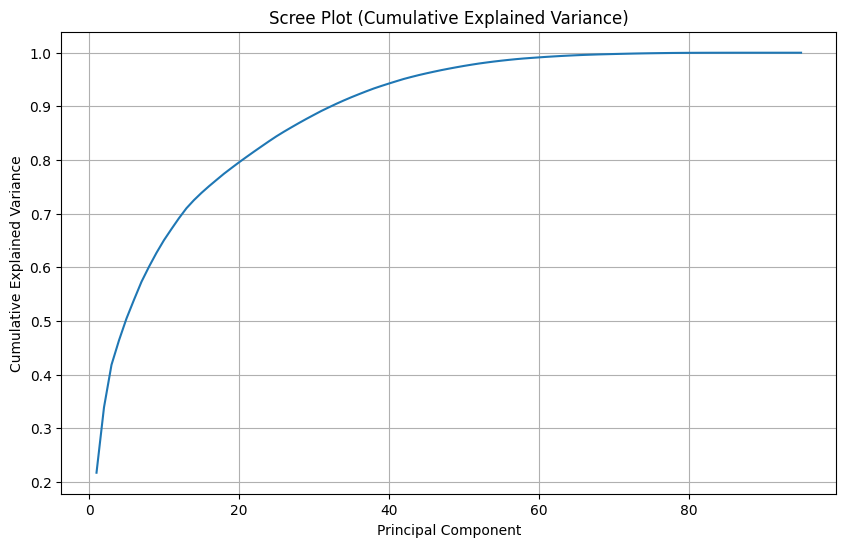

In [ ]:
from sklearn.decomposition import PCA
# Step 1: Apply PCA to reduce dimensionality
pca = PCA(n_components=95)
X_pca = pca.fit_transform(X_scaled)

# Print the explained variance ratio of each principal component
print("Explained variance ratio of each component:")
print(pca.explained_variance_ratio_)

# Explained Variance Ratio Visualization (Scree Plot)
plt.figure(figsize=(10, 6))
sns.lineplot(x=np.arange(1, len(pca.explained_variance_ratio_) + 1), y=np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot (Cumulative Explained Variance)")
plt.grid(True)
plt.show()




<ipython-input-12-580718f07da5>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lasso_selected_features, x='Importance', y='Feature', palette='viridis')


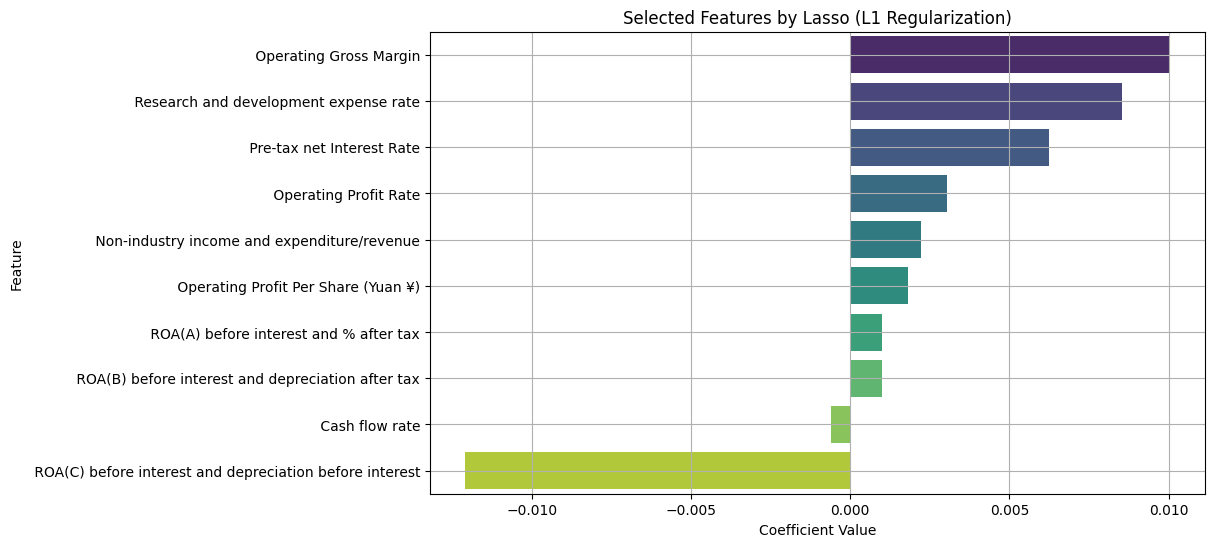


Top selected features by Lasso:
                                              Feature  Importance
3                              Operating Gross Margin    0.010029
11              Research and development expense rate    0.008532
6                           Pre-tax net Interest Rate    0.006251
5                               Operating Profit Rate    0.003034
8         Non-industry income and expenditure/revenue    0.002213
21                Operating Profit Per Share (Yuan ¥)    0.001821
1              ROA(A) before interest and % after tax    0.001010
2    ROA(B) before interest and depreciation after...    0.000993
12                                     Cash flow rate   -0.000607
0    ROA(C) before interest and depreciation befor...   -0.012103


In [ ]:
from sklearn.linear_model import Lasso
# Step 2: Feature Selection with Lasso
lasso = Lasso(alpha=0.010)
lasso.fit(X_pca, y)

# Get the coefficients of the selected features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lasso.coef_
}).sort_values(by='Importance', ascending=False)

# Select only non-zero coefficients
lasso_selected_features = feature_importance[feature_importance['Importance'] != 0]

# Plot selected features by Lasso
plt.figure(figsize=(10, 6))
sns.barplot(data=lasso_selected_features, x='Importance', y='Feature', palette='viridis')
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Selected Features by Lasso (L1 Regularization)")
plt.grid(True)
plt.show()

# Print top selected features
print("\nTop selected features by Lasso:")
print(lasso_selected_features)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Step 3: Train a Random Forest to determine feature importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y)

# Get the feature importances from the random forest
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print top 10 most important features
print("\nTop 10 Features by Importance:")
print(feature_importance_df.head(10))


Top 10 Features by Importance:
                                         Feature  Importance
89            Net Income to Stockholder's Equity    0.029305
39                          Borrowing dependency    0.026796
29                         Net Value Growth Rate    0.024345
18       Persistent EPS in the Last Four Seasons    0.022208
35                    Total debt/Total net worth    0.021423
16                       Net Value Per Share (A)    0.019785
85                    Net Income to Total Assets    0.017816
8    Non-industry income and expenditure/revenue    0.017570
15                       Net Value Per Share (B)    0.017318
91            Degree of Financial Leverage (DFL)    0.016908


<ipython-input-14-5cd2090def3c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


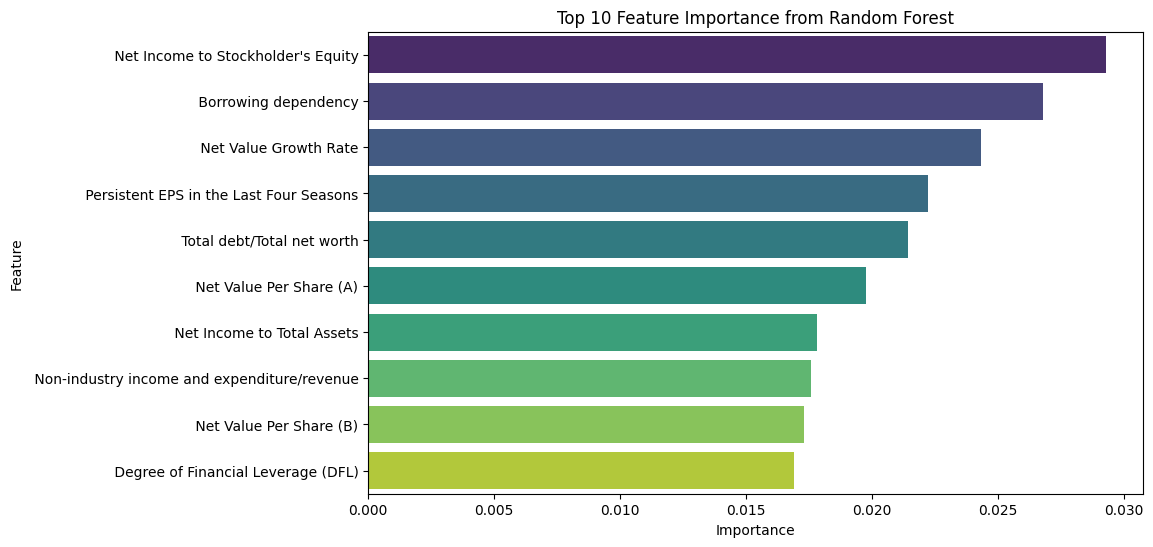

In [ ]:
# Step 4: Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title("Top 10 Feature Importance from Random Forest")
plt.show()



Combined selected features (from both Lasso and Random Forest):
[]


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns



X = data[[" Net Income to Stockholder's Equity",
    " Borrowing dependency",
    " Net Value Growth Rate",
    " Persistent EPS in the Last Four Seasons",
    " Total debt/Total net worth",
    " Net Value Per Share (A)",
    " Net Income to Total Assets",
    " Non-industry income and expenditure/revenue",
    " Net Value Per Share (B)",
    " Degree of Financial Leverage (DFL)"]].values # Features selected

y = data["Bankrupt?"].values     # Target variable




In [ ]:
# Handle class imbalance using SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import randint
pipeline = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))

# Step 5: Hyperparameter tuning using RandomizedSearchCV (instead of GridSearchCV for speed)
param_dist = {
    'randomforestclassifier__n_estimators': randint(100, 500),
    'randomforestclassifier__max_depth': [None, 10, 20, 30],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4]
}

# Perform RandomizedSearchCV to find the best hyperparameters
random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, verbose=2, random_state=42)
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('standardscaler',
                                              StandardScaler()),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'randomforestclassifier__max_depth': [None,
                                                                              10,
                                                                              20,
                                                                              30],
                                        'randomforestclassifier__min_samples_leaf': [1,
                                                                                     2,
                                                                                     4],
                                        'randomforestclassifier__min_samples_split': [2,
                                                                                      5,
                                                                                      10],
                                        'randomforestclassifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x792f96633dc0>},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:

print(f"Best Parameters: {random_search.best_params_}")
best_rf_model = random_search.best_estimator_


Best Parameters: {'randomforestclassifier__max_depth': 30, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 202}


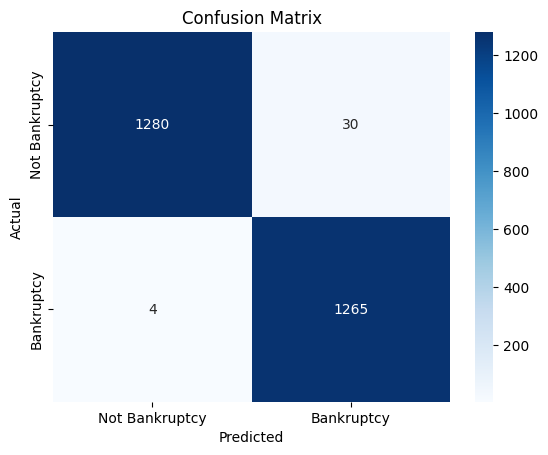

In [ ]:
# Confusion Matrix
y_pred = best_rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Bankruptcy", "Bankruptcy"], yticklabels=["Not Bankruptcy", "Bankruptcy"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


In [ ]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1310
           1       0.98      1.00      0.99      1269

    accuracy                           0.99      2579
   macro avg       0.99      0.99      0.99      2579
weighted avg       0.99      0.99      0.99      2579



In [ ]:
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))


Accuracy Score: 0.986816595579682


In [ ]:
# Step 8: Cross-validation (k-fold)
cv_scores = cross_val_score(best_rf_model, X, y, cv=3, scoring='accuracy')  # Reduced folds for faster computation
print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Average cross-validation score: {cv_scores.mean()}")


Cross-validation accuracy scores: [0.96039604 0.96714671 0.97118415]
Average cross-validation score: 0.9662423018528777


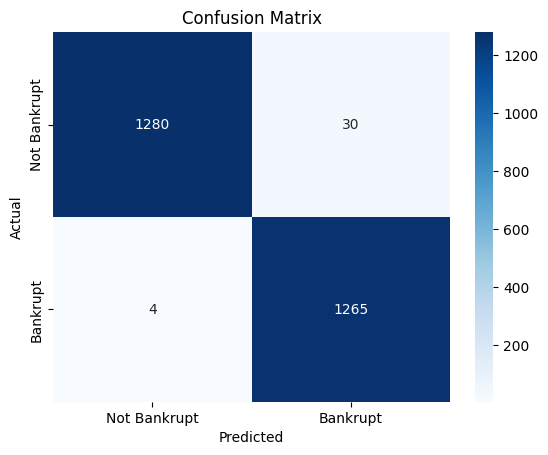

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import seaborn as sns

# Evaluate the model on the test set
y_pred = best_rf_model.predict(X_test)

# Step 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()



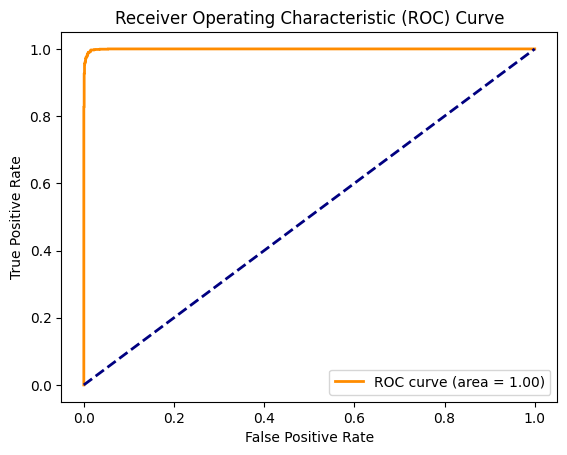

In [ ]:
#  ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()



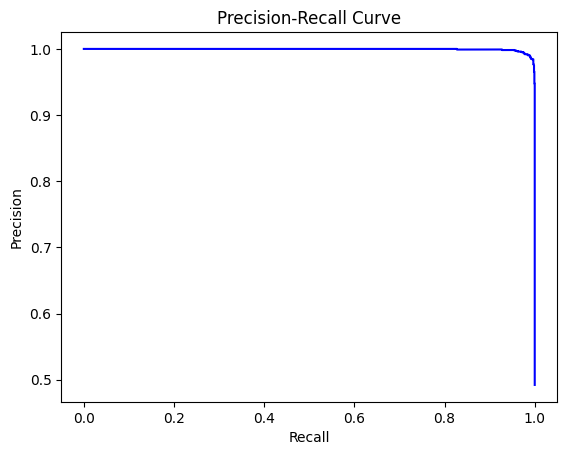

In [ ]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])
plt.plot(recall, precision, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()



In [ ]:
# Step 4: Feature Importance
importances = best_rf_model.named_steps['randomforestclassifier'].feature_importances_

# Get the feature names from the data (excluding the target column)
# Make sure you're selecting only the features used in the model
feature_names = data[[
    " Net Income to Stockholder's Equity",
    " Borrowing dependency",
    " Net Value Growth Rate",
    " Persistent EPS in the Last Four Seasons",
    " Total debt/Total net worth",
    " Net Value Per Share (A)",
    " Net Income to Total Assets",
    " Non-industry income and expenditure/revenue",
    " Net Value Per Share (B)",
    " Degree of Financial Leverage (DFL)"
]].columns.tolist()  # Convert to a list of feature names

# Ensure that feature_names and importances have the same length
if len(feature_names) == len(importances):
    # Create a DataFrame with feature names and their importance
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Plot the top 10 most important features
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
    plt.title("Top 10 Features by Importance")
    plt.show()
else:
    print("Error: Feature names and importances have different lengths.")


Error: Feature names and importances have different lengths.
